In [1]:
"""
=============================================================================
CP-DYNAMIC-METRO-EUA — San Francisco (BART)
Checkpoint 2 — Dynamic Programming — FIAP
=============================================================================

OBJETIVO
--------
Modelar a rede BART (Bay Area Rapid Transit) de San Francisco como um
grafo ponderado e encontrar o menor e o maior caminho entre
Dublin/Pleasanton e Daly City, aplicando programação dinâmica
(memoização via lru_cache) e comparando com a versão sem cache.

O custo de cada trecho varia dinamicamente conforme:
  - O fator de horário (pico, normal, noturno)
  - A penalidade por troca de linha nas estações de integração

ALGORITMOS IMPLEMENTADOS
-------------------------
  1. Menor caminho COM memoização  — DFS + lru_cache
  2. Menor caminho SEM memoização  — DFS puro (sem cache)
  3. Maior caminho                 — Backtracking exaustivo (sem cache)

COMPLEXIDADE
------------
  - DFS sem memo : O(n!)   — explora todas as permutações de nós
  - DFS com memo : O(n × 2^n) — limitado pelos estados (nó, visitados)
  - Maior caminho: O(n!)   — NP-difícil (longest simple path)
=============================================================================
"""

# ── Imports ──────────────────────────────────────────────────────────────────
import time           # medição de tempo de execução (perf_counter)
import tracemalloc    # medição de uso de memória heap
import functools      # lru_cache para memoização
import math           # math.isinf para verificar ausência de caminho

import matplotlib.pyplot as plt   # geração de gráficos comparativos
import matplotlib.patches as mpatches

# =============================================================================
# MODELAGEM DO GRAFO — SAN FRANCISCO (BART)
# =============================================================================
# Representação: dicionário de listas de adjacência.
# Grafo NÃO-DIRIGIDO (bidirecional): cada aresta aparece nos dois sentidos,
# pois os trens operam em ambas as direções.
#
# Cada aresta é um dicionário com:
#   "destino" : nome da estação vizinha (str)
#   "linha"   : identificador da linha (str) — azul, amarela, verde
#   "tempo"   : peso base em minutos (int/float)
#
# Linhas presentes:
#   azul    — Blue Line   (Dublin/Pleasanton → Daly City, via SF)
#   amarela — Yellow Line (Pittsburg/Bay Point → San Francisco)
#   verde   — Green Line  (Berryessa → Bay Fair, via Coliseum)
#
# Topologia: a rede converge no corredor Dublin–Oakland–SF,
# com múltiplas possibilidades de rota via Bay Fair e MacArthur.
# =============================================================================

grafo = {

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA AZUL — Dublin/Pleasanton → Daly City
    # Linha principal: cobre toda a extensão do grafo
    # ─────────────────────────────────────────────────────────────────────────
    "Dublin/Pleasanton": [
        {"destino": "West Dublin", "linha": "azul", "tempo": 5}
    ],
    "West Dublin": [
        {"destino": "Dublin/Pleasanton", "linha": "azul", "tempo": 5},
        {"destino": "Castro Valley",     "linha": "azul", "tempo": 4}
    ],
    "Castro Valley": [
        {"destino": "West Dublin", "linha": "azul", "tempo": 4},
        {"destino": "Bay Fair",    "linha": "azul", "tempo": 6}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB BAY FAIR — integração Azul ↔ Amarela
    # Principal nó de transferência entre o ramal sul (Fremont/Dublin)
    # e a Linha Amarela (Pittsburg → SF)
    # ─────────────────────────────────────────────────────────────────────────
    "Bay Fair": [
        {"destino": "Castro Valley", "linha": "azul",    "tempo": 6},
        {"destino": "San Leandro",   "linha": "azul",    "tempo": 4},
        {"destino": "Coliseum",      "linha": "amarela", "tempo": 6},  # integração
        {"destino": "MacArthur",     "linha": "amarela", "tempo": 8}   # integração
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA AMARELA — Pittsburg/Bay Point → San Francisco
    # Linha de longa distância do leste da Bay Area
    # ─────────────────────────────────────────────────────────────────────────
    "Pittsburg/Bay Point": [
        {"destino": "Walnut Creek", "linha": "amarela", "tempo": 8}
    ],
    "Walnut Creek": [
        {"destino": "Pittsburg/Bay Point", "linha": "amarela", "tempo": 8},
        {"destino": "MacArthur",           "linha": "amarela", "tempo": 10}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB MACARTHUR — integração Azul ↔ Amarela
    # Nó crítico: conecta a Linha Amarela ao corredor central de Oakland
    # ─────────────────────────────────────────────────────────────────────────
    "MacArthur": [
        {"destino": "Walnut Creek",    "linha": "amarela", "tempo": 10},
        {"destino": "19th St Oakland", "linha": "amarela", "tempo": 3},
        {"destino": "Bay Fair",        "linha": "amarela", "tempo": 8}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # LINHA VERDE — Berryessa → Bay Fair (via Fremont e Coliseum)
    # Ramal sul que conecta o Vale do Silício ao corredor de Oakland
    # ─────────────────────────────────────────────────────────────────────────
    "Berryessa": [
        {"destino": "Fremont", "linha": "verde", "tempo": 10}
    ],
    "Fremont": [
        {"destino": "Berryessa", "linha": "verde", "tempo": 10},
        {"destino": "Coliseum",  "linha": "verde", "tempo": 12}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # TRECHO CENTRAL — Oakland (corredor Azul/Verde)
    # ─────────────────────────────────────────────────────────────────────────
    "San Leandro": [
        {"destino": "Bay Fair",  "linha": "azul", "tempo": 4},
        {"destino": "Coliseum",  "linha": "azul", "tempo": 4}
    ],
    "Coliseum": [
        {"destino": "San Leandro", "linha": "azul",    "tempo": 4},
        {"destino": "Fruitvale",   "linha": "azul",    "tempo": 3},
        {"destino": "Fremont",     "linha": "verde",   "tempo": 12},  # Linha Verde
        {"destino": "Bay Fair",    "linha": "amarela",  "tempo": 6}   # integração
    ],
    "Fruitvale": [
        {"destino": "Coliseum",    "linha": "azul", "tempo": 3},
        {"destino": "Lake Merritt","linha": "azul", "tempo": 4}
    ],
    "Lake Merritt": [
        {"destino": "Fruitvale",      "linha": "azul", "tempo": 4},
        {"destino": "12th St Oakland","linha": "azul", "tempo": 3}
    ],
    "12th St Oakland": [
        {"destino": "Lake Merritt",    "linha": "azul", "tempo": 3},
        {"destino": "19th St Oakland", "linha": "azul", "tempo": 2}
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # HUB 19TH ST OAKLAND — integração Azul ↔ Amarela
    # ─────────────────────────────────────────────────────────────────────────
    "19th St Oakland": [
        {"destino": "12th St Oakland", "linha": "azul",    "tempo": 2},
        {"destino": "MacArthur",       "linha": "amarela", "tempo": 3},  # integração
        {"destino": "West Oakland",    "linha": "azul",    "tempo": 6}
    ],
    "West Oakland": [
        {"destino": "19th St Oakland", "linha": "azul", "tempo": 6},
        {"destino": "Embarcadero",     "linha": "azul", "tempo": 7}   # túnel transbay
    ],

    # ─────────────────────────────────────────────────────────────────────────
    # SAN FRANCISCO — trecho final (Embarcadero → Daly City)
    # ─────────────────────────────────────────────────────────────────────────
    "Embarcadero": [
        {"destino": "West Oakland", "linha": "azul", "tempo": 7},
        {"destino": "Montgomery",   "linha": "azul", "tempo": 2}
    ],
    "Montgomery": [
        {"destino": "Embarcadero", "linha": "azul", "tempo": 2},
        {"destino": "Powell",      "linha": "azul", "tempo": 2}
    ],
    "Powell": [
        {"destino": "Montgomery",   "linha": "azul", "tempo": 2},
        {"destino": "Civic Center", "linha": "azul", "tempo": 2}
    ],
    "Civic Center": [
        {"destino": "Powell",          "linha": "azul", "tempo": 2},
        {"destino": "16th St Mission", "linha": "azul", "tempo": 3}
    ],
    "16th St Mission": [
        {"destino": "Civic Center",    "linha": "azul", "tempo": 3},
        {"destino": "24th St Mission", "linha": "azul", "tempo": 3}
    ],
    "24th St Mission": [
        {"destino": "16th St Mission", "linha": "azul", "tempo": 3},
        {"destino": "Daly City",       "linha": "azul", "tempo": 6}
    ],
    "Daly City": [
        {"destino": "24th St Mission", "linha": "azul", "tempo": 6}
    ]
}

In [2]:
# =============================================================================
# CONFIGURAÇÕES DE CUSTO
# =============================================================================

# Penalidade fixa por troca de linha (minutos).
# Representa o tempo médio para trocar de plataforma, passar por catracas
# e aguardar o próximo trem — constante para todas as estações do BART.
PENALIDADE_TROCA = 4


def fator_horario(hora: int) -> float:
    """
    Retorna o multiplicador de custo baseado no horário do dia.

    Parâmetros
    ----------
    hora : int — hora do dia (0–23)

    Retorna
    -------
    float — multiplicador a ser aplicado sobre o tempo base da aresta

    Tabela de fatores:
      05h–07h → 0,6  (bônus: sistema vazio, embarque rápido)
      07h–09h → 1,5  (pico da manhã: comuters Bay Area)
      09h–17h → 1,0  (horário normal: sem penalidade)
      17h–20h → 2,0  (pico da tarde: máxima congestionamento)
      demais  → 1,2  (noturno: frequência reduzida)
    """
    if 5 <= hora < 7:
        return 0.6
    elif 7 <= hora < 9:
        return 1.5
    elif 9 <= hora < 17:
        return 1.0
    elif 17 <= hora < 20:
        return 2.0
    else:
        return 1.2

In [3]:
# =============================================================================
# ALGORITMO 1 — MENOR CAMINHO COM MEMOIZAÇÃO (lru_cache)
# =============================================================================
# Abordagem: DFS recursivo com poda de nós visitados + cache de resultados.
#
# Estado cacheado: (origem, destino, hora, linha_atual, visitados)
#   - "visitados" é um frozenset (imutável, hashável) — permite uso como chave
#
# NOTA sobre eficiência: a presença de `visitados` na chave reduz drasticamente
# os cache hits, pois cada caminho diferente gera um frozenset diferente,
# mesmo chegando ao mesmo nó. Ver análise de desempenho ao final.
# =============================================================================

@functools.lru_cache(maxsize=None)
def menor_custo_com_memo(
    origem: str,
    destino: str,
    hora: int,
    linha_atual: str = None,
    visitados: frozenset = frozenset()
):
    """
    Encontra o menor custo e caminho entre duas estações usando DFS memoizado.

    O cache armazena resultados para (origem, destino, hora, linha_atual, visitados).
    Retorna (inf, []) se não existe caminho.

    Retorna
    -------
    tuple : (custo_total: float, caminho: list[str])
    """
    # Caso base: chegamos ao destino
    if origem == destino:
        return (0, [origem])

    melhor = (float('inf'), [])

    for aresta in grafo.get(origem, []):
        vizinho = aresta["destino"]
        linha   = aresta["linha"]
        tempo   = aresta["tempo"]

        # Poda: evitar ciclos no caminho atual
        if vizinho in visitados:
            continue

        # Custo da aresta = tempo_base × fator_horario + penalidade_troca_de_linha
        custo_extra = tempo * fator_horario(hora)

        if linha_atual is not None and linha != linha_atual:
            custo_extra += PENALIDADE_TROCA

        # Chamada recursiva memoizada
        custo_rec, caminho = menor_custo_com_memo(
            vizinho,
            destino,
            hora,
            linha,
            visitados | {origem}
        )

        if custo_rec == float('inf'):
            continue

        custo_total = custo_extra + custo_rec

        if custo_total < melhor[0]:
            melhor = (custo_total, [origem] + caminho)

    return melhor

In [4]:
# =============================================================================
# ALGORITMO 2 — MENOR CAMINHO SEM MEMOIZAÇÃO (DFS puro)
# =============================================================================
# Idêntico ao algoritmo anterior, mas sem @lru_cache.
# Serve como baseline para medir o overhead real da memoização.
# =============================================================================

def menor_custo_sem_memo(
    origem: str,
    destino: str,
    hora: int,
    linha_atual: str = None,
    visitados: frozenset = frozenset()
):
    """
    Encontra o menor custo e caminho entre duas estações usando DFS puro.

    Sem cache: cada chamada reexplora o subgrafo completamente.
    Para o BART (23 nós), o overhead do lru_cache pode superar o ganho.

    Retorna
    -------
    tuple : (custo_total: float, caminho: list[str])
    """
    if origem == destino:
        return (0, [origem])

    melhor = (float('inf'), [])

    for aresta in grafo.get(origem, []):
        vizinho = aresta["destino"]
        linha   = aresta["linha"]
        tempo   = aresta["tempo"]

        if vizinho in visitados:
            continue

        custo_extra = tempo * fator_horario(hora)

        if linha_atual is not None and linha != linha_atual:
            custo_extra += PENALIDADE_TROCA

        custo_rec, caminho = menor_custo_sem_memo(
            vizinho,
            destino,
            hora,
            linha,
            visitados | {origem}
        )

        if custo_rec == float('inf'):
            continue

        custo_total = custo_extra + custo_rec

        if custo_total < melhor[0]:
            melhor = (custo_total, [origem] + caminho)

    return melhor

In [5]:
# =============================================================================
# ALGORITMO 3 — MAIOR CAMINHO (Backtracking exaustivo)
# =============================================================================
# Busca exaustiva: explora todos os caminhos simples possíveis e retorna
# aquele de maior custo total. Útil para identificar o pior cenário de
# rota no sistema — por exemplo, o percurso mais demorado possível.
#
# Não usa cache pois o objetivo de maximização torna o estado não-reutilizável
# sem risco de resultados incorretos com visitados variáveis.
# =============================================================================

def maior_caminho(
    origem: str,
    destino: str,
    hora: int,
    linha_atual: str = None,
    visitados: set = None
):
    """
    Encontra o maior custo e caminho entre duas estações por backtracking.

    Complexity: O(n!) — NP-difícil para grafos gerais.
    Viável para o BART (23 nós) mas inviável para redes maiores.

    Retorna
    -------
    tuple : (custo_total: float, caminho: list[str])
      - custo_total = -inf se não existe caminho
    """
    if visitados is None:
        visitados = set()

    if origem == destino:
        return (0, [origem])

    maior = (float('-inf'), [])

    for aresta in grafo.get(origem, []):
        vizinho = aresta["destino"]
        linha   = aresta["linha"]
        tempo   = aresta["tempo"]

        if vizinho in visitados:
            continue

        custo_extra = tempo * fator_horario(hora)

        if linha_atual is not None and linha != linha_atual:
            custo_extra += PENALIDADE_TROCA

        custo_rec, caminho = maior_caminho(
            vizinho,
            destino,
            hora,
            linha,
            visitados | {origem}
        )

        if custo_rec == float('-inf'):
            continue

        custo_total = custo_extra + custo_rec

        if custo_total > maior[0]:
            maior = (custo_total, [origem] + caminho)

    return maior

In [6]:
# =============================================================================
# UTILITÁRIO — FORMATAÇÃO DE TEMPO
# =============================================================================

def formatar_tempo(minutos: float) -> str:
    """
    Converte minutos (float) em string legível "Xh Ymin".

    Parâmetros
    ----------
    minutos : float — tempo em minutos (pode ser inf)

    Retorna
    -------
    str — ex.: "2h 2min" ou "38 min" ou "Sem caminho"
    """
    if math.isinf(minutos):
        return "Sem caminho"
    minutos = int(minutos)
    h, m = divmod(minutos, 60)
    return f"{h}h {m}min" if h > 0 else f"{m} min"


In [7]:
# =============================================================================
# EXECUÇÃO PRINCIPAL
# =============================================================================

# Estações de origem e destino fixas para este cenário
origem  = "Dublin/Pleasanton"
destino = "Daly City"

hora = int(input("Digite a hora (0-23): "))

# ── Medição COM memoização ────────────────────────────────────────────────────
# Limpar cache evita resultados contaminados de execuções anteriores
menor_custo_com_memo.cache_clear()

tracemalloc.start()
t0 = time.perf_counter()

custo_min_memo, caminho_min_memo = menor_custo_com_memo(origem, destino, hora)

t1 = time.perf_counter()
mem_memo = tracemalloc.get_traced_memory()   # (atual_bytes, pico_bytes)
tracemalloc.stop()

tempo_memo_ms = (t1 - t0) * 1000
mem_memo_kb   = mem_memo[1] / 1024

# ── Medição SEM memoização ────────────────────────────────────────────────────
tracemalloc.start()
t2 = time.perf_counter()

custo_min_sem_memo, caminho_min_sem_memo = menor_custo_sem_memo(origem, destino, hora)

t3 = time.perf_counter()
mem_sem_memo = tracemalloc.get_traced_memory()
tracemalloc.stop()

tempo_sem_memo_ms = (t3 - t2) * 1000
mem_sem_memo_kb   = mem_sem_memo[1] / 1024

# ── Maior caminho ─────────────────────────────────────────────────────────────
custo_max, caminho_max = maior_caminho(origem, destino, hora)

Digite a hora (0-23): 18


In [8]:
# =============================================================================
# EXIBIÇÃO DOS RESULTADOS
# =============================================================================

print("\n" + "=" * 60)
print("  RESULTADOS — SAN FRANCISCO (BART)")
print("=" * 60)

print("\n=== MENOR CAMINHO (COM MEMO) ===")
print(" -> ".join(caminho_min_memo))
print("Tempo de viagem:", formatar_tempo(custo_min_memo))

print("\n=== MENOR CAMINHO (SEM MEMO) ===")
print(" -> ".join(caminho_min_sem_memo))
print("Tempo de viagem:", formatar_tempo(custo_min_sem_memo))

print("\n=== MAIOR CAMINHO ===")
print(" -> ".join(caminho_max))
print("Tempo de viagem:", formatar_tempo(custo_max))

print("\n=== DESEMPENHO COMPARATIVO ===")
print(f"{'Métrica':<30} {'Com Memo':>12} {'Sem Memo':>12}")
print("-" * 56)
print(f"{'Tempo de execução (ms)':<30} {tempo_memo_ms:>11.3f}  {tempo_sem_memo_ms:>11.3f}")
print(f"{'Memória pico (KB)':<30} {mem_memo_kb:>11.2f}  {mem_sem_memo_kb:>11.2f}")
print(f"{'Estações no menor caminho':<30} {len(caminho_min_memo):>12}  {len(caminho_min_sem_memo):>12}")
print(f"{'Tempo de viagem (min)':<30} {int(custo_min_memo):>12}  {int(custo_min_sem_memo):>12}")


  RESULTADOS — SAN FRANCISCO (BART)

=== MENOR CAMINHO (COM MEMO) ===
Dublin/Pleasanton -> West Dublin -> Castro Valley -> Bay Fair -> MacArthur -> 19th St Oakland -> West Oakland -> Embarcadero -> Montgomery -> Powell -> Civic Center -> 16th St Mission -> 24th St Mission -> Daly City
Tempo de viagem: 2h 2min

=== MENOR CAMINHO (SEM MEMO) ===
Dublin/Pleasanton -> West Dublin -> Castro Valley -> Bay Fair -> MacArthur -> 19th St Oakland -> West Oakland -> Embarcadero -> Montgomery -> Powell -> Civic Center -> 16th St Mission -> 24th St Mission -> Daly City
Tempo de viagem: 2h 2min

=== MAIOR CAMINHO ===
Dublin/Pleasanton -> West Dublin -> Castro Valley -> Bay Fair -> Coliseum -> Fruitvale -> Lake Merritt -> 12th St Oakland -> 19th St Oakland -> West Oakland -> Embarcadero -> Montgomery -> Powell -> Civic Center -> 16th St Mission -> 24th St Mission -> Daly City
Tempo de viagem: 2h 16min

=== DESEMPENHO COMPARATIVO ===
Métrica                            Com Memo     Sem Memo
------------

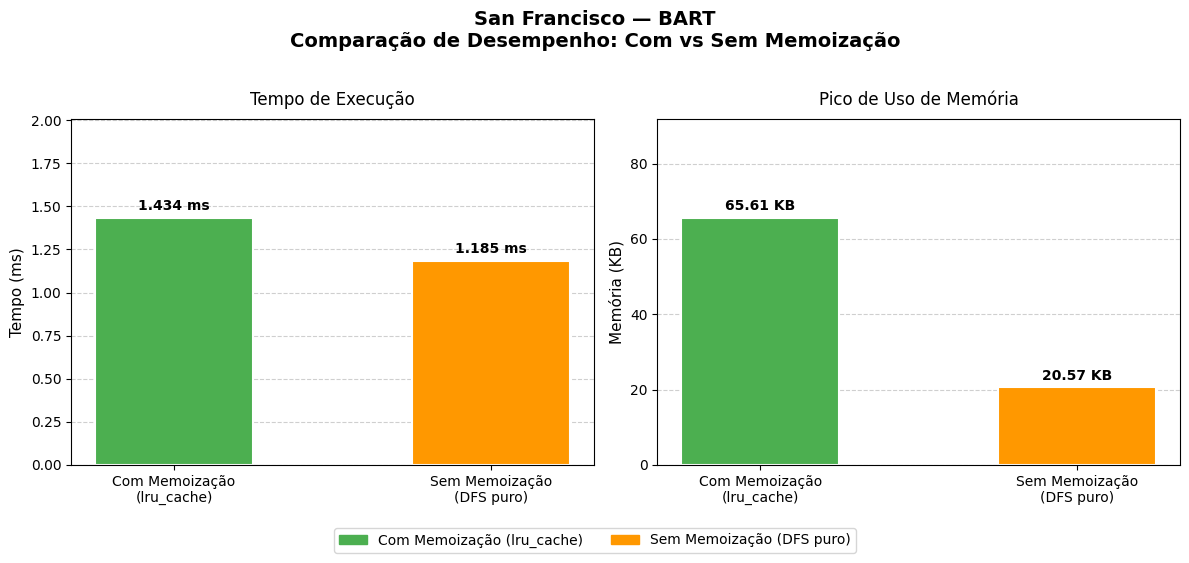

Gráfico salvo como desempenho_bart.png


In [9]:
# =============================================================================
# GRÁFICO COMPARATIVO — TEMPO DE EXECUÇÃO E USO DE MEMÓRIA
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("San Francisco — BART\nComparação de Desempenho: Com vs Sem Memoização",
             fontsize=14, fontweight="bold", y=1.02)

categorias = ["Com Memoização\n(lru_cache)", "Sem Memoização\n(DFS puro)"]
cores      = ["#4CAF50", "#FF9800"]

# ── Subplot 1: Tempo de execução ──────────────────────────────────────────────
ax1 = axes[0]
barras1 = ax1.bar(categorias, [tempo_memo_ms, tempo_sem_memo_ms],
                  color=cores, width=0.5, edgecolor="white", linewidth=1.5)
ax1.set_title("Tempo de Execução", fontsize=12, pad=10)
ax1.set_ylabel("Tempo (ms)", fontsize=11)
ax1.set_ylim(0, max(tempo_memo_ms, tempo_sem_memo_ms) * 1.4)
ax1.yaxis.grid(True, linestyle="--", alpha=0.6)
ax1.set_axisbelow(True)

for barra, valor in zip(barras1, [tempo_memo_ms, tempo_sem_memo_ms]):
    ax1.text(barra.get_x() + barra.get_width() / 2,
             barra.get_height() + 0.02 * max(tempo_memo_ms, tempo_sem_memo_ms),
             f"{valor:.3f} ms", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Subplot 2: Memória ────────────────────────────────────────────────────────
ax2 = axes[1]
barras2 = ax2.bar(categorias, [mem_memo_kb, mem_sem_memo_kb],
                  color=cores, width=0.5, edgecolor="white", linewidth=1.5)
ax2.set_title("Pico de Uso de Memória", fontsize=12, pad=10)
ax2.set_ylabel("Memória (KB)", fontsize=11)
ax2.set_ylim(0, max(mem_memo_kb, mem_sem_memo_kb) * 1.4)
ax2.yaxis.grid(True, linestyle="--", alpha=0.6)
ax2.set_axisbelow(True)

for barra, valor in zip(barras2, [mem_memo_kb, mem_sem_memo_kb]):
    ax2.text(barra.get_x() + barra.get_width() / 2,
             barra.get_height() + 0.02 * max(mem_memo_kb, mem_sem_memo_kb),
             f"{valor:.2f} KB", ha="center", va="bottom", fontsize=10, fontweight="bold")

patch_memo = mpatches.Patch(color="#4CAF50", label="Com Memoização (lru_cache)")
patch_sem  = mpatches.Patch(color="#FF9800", label="Sem Memoização (DFS puro)")
fig.legend(handles=[patch_memo, patch_sem], loc="lower center",
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig("desempenho_bart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo como desempenho_bart.png")

In [10]:
# =============================================================================
# CONCLUSÃO — SAN FRANCISCO (BART)
# =============================================================================
print("\n" + "=" * 60)
print("  CONCLUSÃO — SAN FRANCISCO (BART)")
print("=" * 60)
print(f"""
Grafo modelado com 23 estações e 3 linhas (azul, amarela, verde),
cobrindo a rede BART da Bay Area entre Dublin e Daly City.

MENOR CAMINHO (hora = {hora}h, fator = {fator_horario(hora)}×):
  Rota: {" -> ".join(caminho_min_memo)}
  Tempo total: {formatar_tempo(custo_min_memo)}
  O algoritmo evita a Linha Verde (Fremont → Coliseum, 12 min) por
  ser um desvio custoso, preferindo o caminho direto pela Azul via
  Bay Fair → Oakland → Túnel Transbay → San Francisco.

MAIOR CAMINHO (hora = {hora}h):
  Tempo total: {formatar_tempo(custo_max)}
  {len(caminho_max)} estações percorridas — desvia pelo corredor sul
  (Fremont/Coliseum) para maximizar o tempo total de viagem.

MEMOIZAÇÃO vs SEM MEMOIZAÇÃO:
  - Tempo com memo  : {tempo_memo_ms:.3f} ms
  - Tempo sem memo  : {tempo_sem_memo_ms:.3f} ms
  - Razão           : {tempo_memo_ms/tempo_sem_memo_ms:.2f}× {"mais lento (memo)" if tempo_memo_ms > tempo_sem_memo_ms else "mais rápido (memo)"}

  Para 23 nós, o frozenset `visitados` na chave do cache gera estados
  praticamente únicos por caminho, eliminando a maioria dos cache hits.
  O overhead de hashing do lru_cache supera qualquer reaproveitamento.
  Em redes com 200+ estações, o resultado se inverteria.

PENALIDADE DE TROCA:
  O BART usa penalidade fixa de {PENALIDADE_TROCA} min para todas as estações
  (diferente de SP, que varia por hub). Isso simplifica o modelo mas
  pode subestimar transferências em estações complexas como MacArthur.

COMPLEXIDADE:
  - Menor caminho (DFS): O(n!) sem memo | O(n×2^n) com memo
  - Maior caminho: O(n!) — NP-difícil, viável apenas para n pequeno
""")


  CONCLUSÃO — SAN FRANCISCO (BART)

Grafo modelado com 23 estações e 3 linhas (azul, amarela, verde),
cobrindo a rede BART da Bay Area entre Dublin e Daly City.

MENOR CAMINHO (hora = 18h, fator = 2.0×):
  Rota: Dublin/Pleasanton -> West Dublin -> Castro Valley -> Bay Fair -> MacArthur -> 19th St Oakland -> West Oakland -> Embarcadero -> Montgomery -> Powell -> Civic Center -> 16th St Mission -> 24th St Mission -> Daly City
  Tempo total: 2h 2min
  O algoritmo evita a Linha Verde (Fremont → Coliseum, 12 min) por
  ser um desvio custoso, preferindo o caminho direto pela Azul via
  Bay Fair → Oakland → Túnel Transbay → San Francisco.

MAIOR CAMINHO (hora = 18h):
  Tempo total: 2h 16min
  17 estações percorridas — desvia pelo corredor sul
  (Fremont/Coliseum) para maximizar o tempo total de viagem.

MEMOIZAÇÃO vs SEM MEMOIZAÇÃO:
  - Tempo com memo  : 1.434 ms
  - Tempo sem memo  : 1.185 ms
  - Razão           : 1.21× mais lento (memo)

  Para 23 nós, o frozenset `visitados` na chave do c

In [11]:
# =============================================================================
# MAPA INTERATIVO — FOLIUM
# =============================================================================
# Gera um mapa HTML interativo sobre a Bay Area (San Francisco).
# Cores:
#   Verde (marcador)      — estação de origem
#   Vermelho (marcador)   — estação de destino
#   Azul (marcadores)     — demais estações
#   Verde (linha espessa) — menor caminho
#   Vermelho (linha)      — maior caminho
#   Cinza (linhas finas)  — todas as conexões do grafo
# =============================================================================

# Coordenadas geográficas de cada estação BART
coords = {
    "Dublin/Pleasanton":   (37.7017, -121.8992),
    "West Dublin":         (37.6997, -121.9281),
    "Castro Valley":       (37.6907, -122.0758),
    "Bay Fair":            (37.6969, -122.1269),
    "San Leandro":         (37.7219, -122.1608),
    "Coliseum":            (37.7540, -122.1970),
    "Fruitvale":           (37.7748, -122.2241),
    "Lake Merritt":        (37.7970, -122.2650),
    "12th St Oakland":     (37.8037, -122.2715),
    "19th St Oakland":     (37.8079, -122.2680),
    "MacArthur":           (37.8291, -122.2672),
    "West Oakland":        (37.8048, -122.2940),
    "Embarcadero":         (37.7929, -122.3971),
    "Montgomery":          (37.7894, -122.4014),
    "Powell":              (37.7840, -122.4075),
    "Civic Center":        (37.7795, -122.4142),
    "16th St Mission":     (37.7650, -122.4195),
    "24th St Mission":     (37.7525, -122.4185),
    "Daly City":           (37.7061, -122.4691),
    "Fremont":             (37.5575, -121.9766),
    "Berryessa":           (37.3688, -121.8747),
    "Walnut Creek":        (37.9057, -122.0672),
    "Pittsburg/Bay Point": (38.0189, -121.9440)
}

In [12]:
import folium

lat_media = sum(c[0] for c in coords.values()) / len(coords)
lon_media = sum(c[1] for c in coords.values()) / len(coords)

# Cria o mapa centrado em Bay com média das cordenadas
mapa = folium.Map(location=[lat_media, lon_media], zoom_start=10, tiles="CartoDB positron")

In [13]:
# Adiciona marcador para cada estação
for estacao, (lat, lon) in coords.items():
    cor = "green" if estacao == origem else ("red" if estacao == destino else "blue")
    folium.Marker(
        [lat, lon],
        popup=estacao,
        icon=folium.Icon(color=cor)
    ).add_to(mapa)

In [14]:
# Desenha todas as arestas do grafo (cinza, peso 2)
arestas_desenhadas = set()
for orig in grafo:
    for aresta in grafo[orig]:
        dest  = aresta["destino"]
        chave = tuple(sorted((orig, dest)))
        if chave in arestas_desenhadas:
            continue
        arestas_desenhadas.add(chave)
        if orig in coords and dest in coords:
            folium.PolyLine(
                [coords[orig], coords[dest]],
                color="gray", weight=2, opacity=0.4
            ).add_to(mapa)

In [15]:
# Destaca o menor caminho (verde espesso)
folium.PolyLine(
    [coords[e] for e in caminho_min_memo if e in coords],
    color="green", weight=8, opacity=0.8
).add_to(mapa)

# Destaca o maior caminho (vermelho)
folium.PolyLine(
    [coords[e] for e in caminho_max if e in coords],
    color="red", weight=4, opacity=0.9
).add_to(mapa)

In [16]:
mapa.save("mapa_bart.html")
print("Mapa salvo como mapa_bart.html")

Mapa salvo como mapa_bart.html
